# 2. Detekcja pierwszoplanowych obiektów ruchomych

In [92]:
from cv2.typing import MatLike
from matplotlib import pyplot as plt


def show_img(img: MatLike, cmap: str | None = None) -> None:
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

In [93]:
TEST_IMG_INDEX = 349

## 2.1. Wczytywanie sekwencji obrazów

In [94]:
from enum import Enum


class DataSet(Enum):
    HIGHWAY="highway"
    OFFICE="office"
    PEDESTRIAN="pedestrian"

In [122]:
from collections.abc import Sequence
from pathlib import Path
from typing import NamedTuple

import cv2
import numpy as np

class Roi(NamedTuple):
    start: int
    end: int

def load_img_sequence(data_set: DataSet) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"input"
    return [np.astype(img, np.int16) for file_name in dataset_dir.iterdir() if (img := cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)) is not None]

def load_img_sequence_results(data_set: DataSet) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"groundtruth"
    return [np.astype((img==255)*255, np.int16) for file_name in dataset_dir.iterdir() if (img := cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)) is not None]

def load_roi(data_set: DataSet) -> Roi:
    roi = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"temporalROI.txt"
    return Roi(*[int(v) for v in roi.read_text("utf-8").split(" ")])

In [96]:
img_sequence = load_img_sequence(DataSet.PEDESTRIAN)
len(img_sequence)

1099

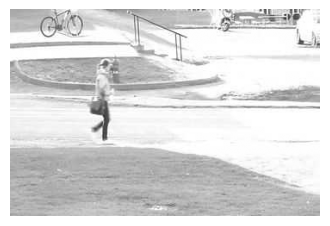

In [97]:
show_img(img_sequence[TEST_IMG_INDEX], 'gray')

## 2.2. Odejmowanie ramek i binaryzacja

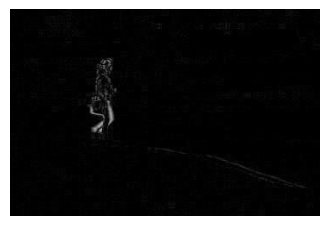

In [98]:
from itertools import pairwise

img_diff_sequence = [
    cv2.absdiff(img_sequence[i_left], img_sequence[i_right]).astype(np.uint8)
    for i_left, i_right in pairwise(range(len(img_sequence)))
]
show_img(img_diff_sequence[TEST_IMG_INDEX], 'gray')

In [99]:
print(len(img_diff_sequence))

1098


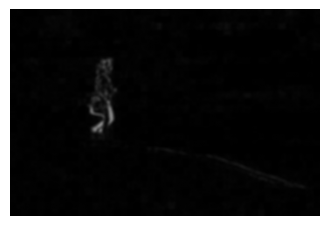

In [100]:
img_gauss_sequence = [
    cv2.GaussianBlur(img, (5, 5), 1.5)
    for img in img_diff_sequence
]
show_img(img_gauss_sequence[TEST_IMG_INDEX], 'gray')

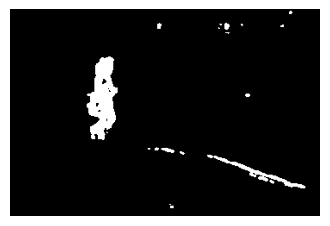

9.0


In [101]:
img_binary_sequence = [
    cv2.threshold(img, 67, 255, cv2.THRESH_TRIANGLE)
    for img in img_gauss_sequence
]
show_img(img_binary_sequence[TEST_IMG_INDEX][1], 'gray')
print(img_binary_sequence[TEST_IMG_INDEX][0])

In [102]:
thresholds = [i[0] for i in img_binary_sequence]

print(f"min: {np.min(thresholds)}")
print(f"max: {np.max(thresholds)}")
print(f"mean: {np.mean(thresholds)}")

min: 5.0
max: 13.0
mean: 7.728597449908925


## 2.3. Operacje morfologiczne

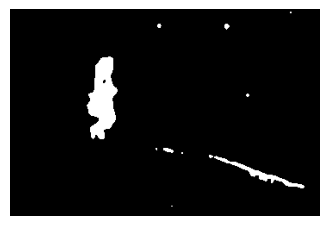

In [103]:
img_median_sequence = [
    cv2.medianBlur(img[1], ksize=5)
    for img in img_binary_sequence
]
show_img(img_median_sequence[TEST_IMG_INDEX], 'gray')

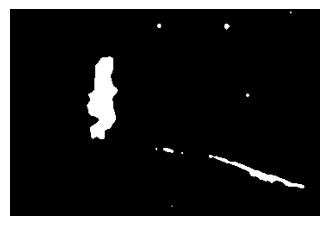

In [104]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
img_morph_sequence = [
    cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    for img in img_median_sequence
]
show_img(img_morph_sequence[TEST_IMG_INDEX], 'gray')

## 2.4. Indeksacja i prosta analiza

In [105]:
class CC(Enum):
    RETVAL=0
    LABELS=1
    STATS=2
    CENTROIDS=3

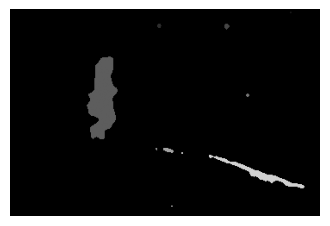

Number of labels: 11


In [106]:
img_cc_sequence = [
    cv2.connectedComponentsWithStats(img)
    for img in img_morph_sequence
]

retval, labels, stats, centroids = img_cc_sequence[TEST_IMG_INDEX]
show_img(labels/retval*255, "gray")
print(f"Number of labels: {retval}")

In [107]:
img_biggest_label_sequence = [
    np.argmax(img[CC.STATS.value][1:, cv2.CC_STAT_AREA])+1
    for img in img_cc_sequence
]

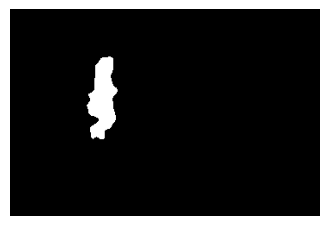

In [123]:
img_biggest_object_sequence = [
    np.astype((img[CC.LABELS.value]==biggest)*255, np.uint8)
    for img, biggest in zip(img_cc_sequence, img_biggest_label_sequence, strict=True)
]
show_img(img_biggest_object_sequence[TEST_IMG_INDEX], "gray")

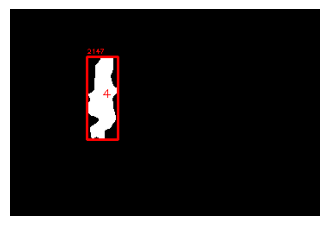

Label with index 4 is the biggest with area of 2147


In [109]:
biggest_object = img_biggest_object_sequence[TEST_IMG_INDEX]
biggest_object_rgb = cv2.cvtColor(biggest_object.astype(np.uint16), cv2.COLOR_GRAY2RGB)

biggest_label = img_biggest_label_sequence[TEST_IMG_INDEX]
biggest_label_stats = stats[biggest_label]


p1 = (biggest_label_stats[cv2.CC_STAT_LEFT], biggest_label_stats[cv2.CC_STAT_TOP])
p2 = (p1[0]+biggest_label_stats[cv2.CC_STAT_WIDTH], p1[1]+biggest_label_stats[cv2.CC_STAT_HEIGHT])
cv2.rectangle(biggest_object_rgb, p1, p2, (255, 0, 0), 2)
cv2.putText(biggest_object_rgb, f"{biggest_label}", [int(v) for v in centroids[biggest_label]], 1, 1, (255, 0, 0))
cv2.putText(biggest_object_rgb, f"{biggest_label_stats[cv2.CC_STAT_AREA]}", (biggest_label_stats[cv2.CC_STAT_LEFT], biggest_label_stats[cv2.CC_STAT_TOP]-4), 1, 0.5, (255, 0, 0))
show_img(biggest_object_rgb)

print(f"Label with index {biggest_label} is the biggest with area of {biggest_label_stats[cv2.CC_STAT_AREA]}")

## 2.5. Ewaluacja wyników detekcji obiektów pierwszoplanowych

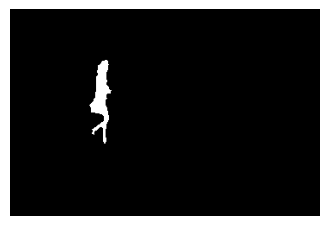

1099


In [117]:
img_sequence_result = load_img_sequence_results(DataSet.PEDESTRIAN)
show_img(img_sequence_result[TEST_IMG_INDEX], 'gray')
print(len(img_sequence_result))

In [125]:
start, stop = load_roi(DataSet.PEDESTRIAN)

In [190]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Metrics:
    tp: int
    tn: int
    fp: int
    fn: int

    def precision(self) -> float:
        if (buf:=self.tp+self.fp) == 0:
            return 0
        return float(self.tp)/buf

    def recall(self) -> float:
        if (buf:=self.tp+self.fn) == 0:
            return 0
        return float(self.tp)/buf
    
    def f1(self) -> float:
        precision = self.precision()
        recall = self.recall()
        if (buf:=precision+recall) == 0:
            return 0
        return (2*precision*recall)/buf
    
    @classmethod
    def compare_labels(cls, labels_pred: MatLike, labels_true: MatLike) -> "Metrics":
        return Metrics(
            tp=np.sum((labels_true == 255) & (labels_pred == 255)),
            tn=np.sum((labels_true == 0) & (labels_pred == 0)),
            fp=np.sum((labels_true == 0) & (labels_pred == 255)),
            fn=np.sum((labels_true == 255) & (labels_pred == 0))
        )

In [164]:
print(f"{len(img_biggest_object_sequence) = }")
print(f"{len(img_sequence_result) = }")
print(f"{start = }")
print(f"{stop = }")

len(img_biggest_object_sequence) = 1098
len(img_sequence_result) = 1099
start = 300
stop = 1099


In [165]:
img_sequence_pred = np.zeros_like(img_sequence_result)
img_sequence_pred[1:] = img_biggest_object_sequence
len(img_sequence_pred)

1099

In [171]:
Metrics.compare_labels(img_sequence_pred[-1], img_sequence_result[-1])

Metrics(tp=np.int64(0), tn=np.int64(86302), fp=np.int64(98), fn=np.int64(0))

In [194]:
img_metrics_sequence = [
    Metrics.compare_labels(img_sequence_pred[i], img_sequence_result[i])
    for i in range(start, stop)
]

In [179]:
len(img_metrics_sequence)

798

In [195]:
mean_precision = np.mean([m.precision() for m in img_metrics_sequence])
mean_recall = np.mean([m.recall() for m in img_metrics_sequence])

print(mean_precision)
print(mean_recall)

0.32329208825463773
0.6383382936739509


In [196]:
mean_f1 = np.mean([m.f1() for m in img_metrics_sequence])

print(mean_f1)

0.42284721477340603
